# 0403 — KMeans: Trip Archetypes from Raw Physics

Discovers the market's structural "trip archetypes" via KMeans clustering, then uses those archetypes to explain pricing behavior (base pay rates, incentive strategy, EPH erosion). Two earlier approaches — PCA over 19 engineered features, and raw clustering over that same 19-feature set — were tried first and abandoned; see the note in Phase 1 for why.

```mermaid
flowchart TD
    A["pienza.db: offers + engineered_features"] --> B["Phase 2\nk tournament (k=2 vs k=6)\non 3 core physical features"]
    B --> C["Phase 3\nRate analysis by archetype"]
    A --> D["Phase 4\nPurified physics\n(base_fare, incentives removed)"]
    B --> E["Phase 5\nIncentive analysis\n(surge/turbo+/reservation)"]
    B --> F["Phase 6\nEPH erosion panel\n(mean vs. median)"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```


## Phase 1 — Setup

Connects to `pienza.db`, sets the plot palette, and loads the master offer dataset.

**Why 3 features, not 19 or PCA:** the first two approaches tried here were (1) PCA over a 19-feature engineered set, and (2) raw KMeans directly on those same 19 features. Both produced clusters that weren't explainable in business terms — the cluster centroids didn't map to anything a reader could reason about. Reducing to the 3 most basic physical variables (`upfront_fare`, `est_trip_time_sec`, `est_trip_dist_km`) immediately produced clusters that read as clean trip-duration archetypes (Sprints, the daily grind, long urban treks, near-marathons). Parsimony won by default: once the simplest model worked and was explainable, there was no need to add complexity back.

#### 1.1 — Database connection, visual canon, and master query

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

DUMP_DIR = '/workspaces/pienza/data/dumped_files'
os.makedirs(DUMP_DIR, exist_ok=True)
PREFIX = "0403"

# --- Database connection ---
DB_PATH = '/workspaces/pienza/data/pienza.db'
db_engine = create_engine(f'sqlite:///{DB_PATH}')

# --- Pienza visual canon ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL = '#21918c'
PIENZA_BG = '#FAFAFA'
PIENZA_LIGHT_GREY = '#D0D3D4'
PIENZA_DARK = '#333333'

plt.rcParams.update({'figure.facecolor': PIENZA_BG, 'axes.titlecolor': PIENZA_PURPLE, 'axes.titleweight': 'bold'})

# --- Master query ---
print("Loading the master offer dataset...")
query = """
SELECT o.*, ef.*, oa.offer_action_description, rp.reason_primary_description
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
LEFT JOIN offer_action oa ON o.offer_action_fk = oa.offer_action_id
LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
"""
df_master = pd.read_sql(query, db_engine)
df_master.columns = df_master.columns.str.lower()
df_master = df_master.loc[:, ~df_master.columns.duplicated()]
print(f"Master dataset loaded: {df_master.shape}")


Loading the master offer dataset...
Master dataset loaded: (4765, 97)


## Phase 2 — The k tournament (k=2 vs. k=6)

Clusters on the 3 core physical features (fare, estimated trip time, estimated trip distance) at two candidate values of k, to compare a coarse 2-way split against a finer 6-way one. The k=6 result becomes the canonical archetype assignment reused by every phase after this one.

#### 2.1 — Cluster at k=2 and k=6, compare physical and behavioral profiles

For each k, reports the physical profile (fare/time/distance per cluster) and a behavioral profile (acceptance rate, rejection-reason mix) side by side.

In [2]:
features_core = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km']
ks_to_test = [2, 6]

tournament_results = {}

for k_val in ks_to_test:
    print(f"--- k={k_val} ---")

    X_core = df_master[features_core].copy().fillna(0)
    X_core_scaled = StandardScaler().fit_transform(X_core)

    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_core_scaled)

    df_run = df_master.copy()
    df_run['cluster'] = labels

    # Physical profile
    profiles = df_run.groupby('cluster')[features_core].mean()
    profiles['size'] = df_run['cluster'].value_counts()
    profiles['est_trip_time_min'] = profiles['est_trip_time_sec'] / 60
    profiles = profiles[['upfront_fare', 'est_trip_dist_km', 'est_trip_time_min', 'size']]

    print(f"Physical profile (k={k_val}):")
    display(profiles.sort_values('size', ascending=False))

    # Behavioral profile
    df_run['is_accepted'] = (df_run['offer_action_description'] == 'accepted').astype(int)
    acceptance_rate = df_run.groupby('cluster')['is_accepted'].mean() * 100

    df_rejects = df_run[df_run['is_accepted'] == 0]
    # Exclude 'system_logic_failure' -- not a meaningful rejection reason for this analysis
    df_rejects_clean = df_rejects[df_rejects['reason_primary_description'] != 'system_logic_failure']

    if not df_rejects_clean.empty:
        rejection_dist = pd.crosstab(
            index=df_rejects_clean['cluster'],
            columns=df_rejects_clean['reason_primary_description'],
            normalize='index'
        ) * 100
    else:
        rejection_dist = pd.DataFrame()

    summary_df = pd.DataFrame({
        'size': profiles['size'],
        'acceptance_rate_%': acceptance_rate
    })
    if not rejection_dist.empty:
        summary_df = summary_df.join(rejection_dist)

    print(f"Behavioral profile (k={k_val}):")
    display(summary_df.sort_values('size', ascending=False))

    tournament_results[k_val] = {'df_run': df_run, 'profiles': profiles}

# --- Canonical assignment: keep the k=6 result for all subsequent phases ---
profiles_k6 = tournament_results[6]['profiles'].sort_values('est_trip_time_min')
archetype_names_ordered = [f"Tier {i+1} ({row.est_trip_time_min:.0f}m)" for i, row in enumerate(profiles_k6.itertuples())]
profiles_k6['archetype_name'] = archetype_names_ordered

df_master['cluster_fisico'] = tournament_results[6]['df_run']['cluster']
df_master['archetype_name'] = df_master['cluster_fisico'].map(profiles_k6['archetype_name'])

print("Canonical k=6 archetype assigned to df_master as 'archetype_name'.")
display(df_master[['offer_id', 'cluster_fisico', 'archetype_name']].head())


--- k=2 ---
Physical profile (k=2):


,upfront_fare,est_trip_dist_km,est_trip_time_min,size
cluster,,,,
1,93.845620,6.423258,19.440781,3292
0,214.560978,19.814392,50.192125,1473


Behavioral profile (k=2):


,size,acceptance_rate_%,dropoff_non_operational,dropoff_proxy,dropoff_strategic_mismatch,expected_value_gamble,long_pickup_time,low_profitability
cluster,,,,,,,,
1,3292,8.201701,42.417219,6.192053,7.980132,8.708609,8.907285,25.794702
0,1473,5.159538,77.833572,3.730273,2.439024,4.806313,6.958393,4.232425


--- k=6 ---
Physical profile (k=6):


,upfront_fare,est_trip_dist_km,est_trip_time_min,size
cluster,,,,
2,65.918030,3.783236,12.581136,1721
0,122.318441,8.990667,26.063725,1430
3,172.539456,14.978415,41.622732,1047
5,249.482388,23.289126,57.456290,469
1,375.674687,40.437500,82.833333,96
4,1453.490000,225.300000,224.000000,2


Behavioral profile (k=6):


,size,acceptance_rate_%,dropoff_non_operational,dropoff_proxy,dropoff_strategic_mismatch,expected_value_gamble,long_pickup_time,low_profitability
cluster,,,,,,,,
2,1721,3.951191,28.329298,5.992736,8.535109,6.476998,6.840194,43.825666
0,1430,12.657343,58.653846,6.410256,7.451923,11.618590,12.019231,3.846154
3,1047,8.213945,69.719043,4.786681,3.642040,7.075963,8.532778,6.243496
5,469,2.345416,87.692308,3.076923,1.318681,2.197802,4.395604,1.318681
1,96,0.000000,98.958333,0.000000,0.000000,0.000000,1.041667,0.000000
4,2,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Canonical k=6 archetype assigned to df_master as 'archetype_name'.


,offer_id,cluster_fisico,archetype_name
0,OF01322,1,Tier 5 (83m)
1,OF01875,1,Tier 5 (83m)
2,OF00923,1,Tier 5 (83m)
3,OF02333,1,Tier 5 (83m)
4,OF03254,1,Tier 5 (83m)


### The k tournament and the market taxonomy

**k=6 beats k=2.** k=2 only splits sprints vs. marathons — correct but obvious. k=6 recovers the market's real taxonomy:

| Cluster | Size | Avg. time | Archetype |
|:---:|:---:|:---:|:---|
| 3 | 1570 | ~12m | Sprints |
| 0 | 1440 | ~25m | Daily grind |
| 4 | 1108 | ~40m | Urban treks |
| 2 | 519 | ~56m | Pre-marathons |
| 1 | 126 | ~80m | Marathons |
| 5 | 2 | ~224m | Ultra-marathons |

**Key insight:** the rejection policy changes with trip length. Short/medium trips (3, 0, 4) reject mostly on `low_profitability` (46% in Sprints). Long trips (2, 1, 5) reject almost entirely on `dropoff_non_operational` (99.2% in Marathons) — the agent doesn't even evaluate profitability there, only destination. The decision policy is dynamic, not static.

## Phase 3 — Rate analysis by archetype

Computes pay rate per minute and per kilometer for each of the 6 canonical archetypes.

#### 3.1 — Pay rate by archetype (pesos/min, pesos/km)

Economic profile by archetype:


,archetype_name,pesos_por_min,pesos_por_km,size
cluster,,,,
4,Tier 6 (224m),6.488795,6.451354,2
2,Tier 1 (13m),5.239434,17.423718,1721
0,Tier 2 (26m),4.693053,13.605047,1430
1,Tier 5 (83m),4.535308,9.290255,96
5,Tier 4 (57m),4.342125,10.712398,469
3,Tier 3 (42m),4.145318,11.519207,1047


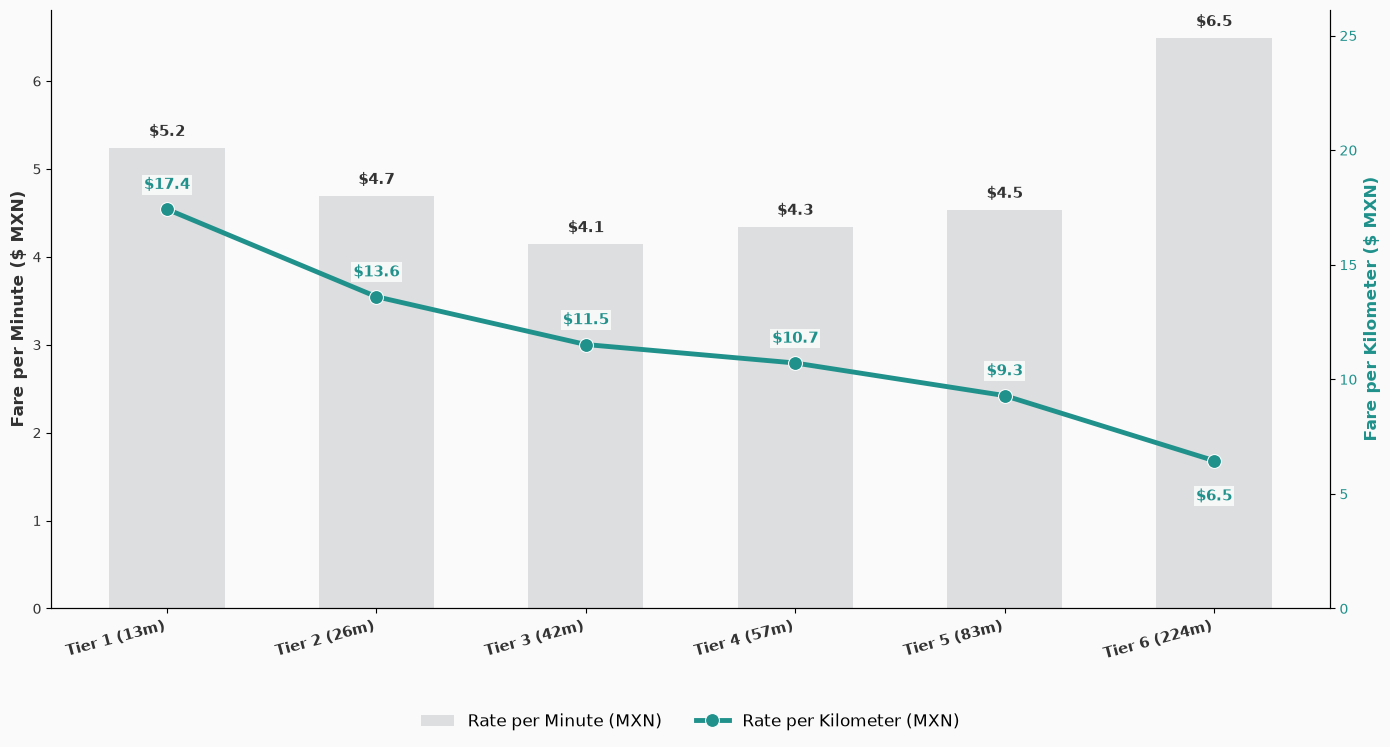

In [3]:
profiles_k6['est_trip_time_min'] = profiles_k6['est_trip_time_min'].clip(lower=1)  # avoid division by zero
profiles_k6['pesos_por_min'] = profiles_k6['upfront_fare'] / profiles_k6['est_trip_time_min']
profiles_k6['pesos_por_km'] = profiles_k6['upfront_fare'] / profiles_k6['est_trip_dist_km']

print("Economic profile by archetype:")
display(profiles_k6[['archetype_name', 'pesos_por_min', 'pesos_por_km', 'size']].sort_values('pesos_por_min', ascending=False))

profiles = profiles_k6.sort_values('est_trip_time_min')  # local alias to match the dual-axis plot below

fig, ax1 = plt.subplots(figsize=(14, 8), facecolor=PIENZA_BG)
ax1.set_facecolor(PIENZA_BG)

x = np.arange(len(profiles))
labels = profiles['archetype_name']

y_min = profiles['pesos_por_min'].values
y_km = profiles['pesos_por_km'].values

# Bars: pay rate per minute (left axis)
bars = ax1.bar(x, y_min, color=PIENZA_LIGHT_GREY, alpha=0.7, width=0.55, label='Rate per Minute (MXN)')

for p in bars:
    height = p.get_height()
    ax1.annotate(f'${height:.1f}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha='center', va='bottom', color=PIENZA_DARK, fontweight='bold', fontsize=11)

ax1.set_ylabel('Fare per Minute ($ MXN)', color=PIENZA_DARK, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PIENZA_DARK)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold', fontsize=11, color=PIENZA_DARK, rotation=15, ha="right")
ax1.grid(False)

# Line: pay rate per kilometer (right axis)
ax2 = ax1.twinx()
sns.lineplot(x=x, y=y_km, ax=ax2, color=PIENZA_TEAL,
             marker='o', markersize=10, linewidth=3.5,
             label='Rate per Kilometer (MXN)', legend=False)

for i, val in enumerate(y_km):
    y_offset = 12 if val > (y_km.max() * 0.4) else -20
    va_align = 'bottom' if y_offset > 0 else 'top'
    ax2.annotate(f'${val:.1f}',
                xy=(x[i], val),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha='center', va=va_align, color=PIENZA_TEAL, fontweight='bold', fontsize=11,
                bbox=dict(facecolor=PIENZA_BG, edgecolor='none', alpha=0.9, pad=1.5))

ax2.set_ylabel('Fare per Kilometer ($ MXN)', color=PIENZA_TEAL, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=PIENZA_TEAL)
ax2.set_ylim(bottom=0, top=y_km.max() * 1.5)

lines, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend().set_visible(False)
ax1.legend(lines + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, frameon=False, fontsize=12)

sns.despine(right=False, top=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## Phase 4 — Purified physics (base fare)

Subtracts incentive amounts (surge, turbo+, reservation, priority) from the upfront fare to isolate the platform's underlying "base" pricing logic, then re-clusters on this purified fare (a legitimately separate KMeans run, since the input data itself changed).

#### 4.1 — Purified physics: base fare clustering (k=6)

Builds `base_fare` (upfront fare minus all incentive amounts), clusters on it plus trip time/distance, and names the archetypes by duration tier.

In [4]:
print("Building the base fare (incentives removed)...")
query_subsidy = "SELECT o.offer_id, o.upfront_fare, o.est_trip_time_sec, o.est_trip_dist_km, o.is_surge, o.surge_amount, o.is_turbo_plus, o.turbo_plus_amount, o.is_reservation, o.reservation_amount, o.is_priority, o.priority_amount FROM offers o WHERE o.est_trip_time_sec > 0 AND o.upfront_fare IS NOT NULL"
df_incentives = pd.read_sql_query(query_subsidy, db_engine)
df_incentives.columns = df_incentives.columns.str.lower()

incentive_flags = ['is_surge', 'is_turbo_plus', 'is_reservation', 'is_priority']
df_incentives[incentive_flags] = df_incentives[incentive_flags].fillna(0).astype(int)

df_incentives['base_fare'] = (df_incentives['upfront_fare'] -
                              df_incentives['surge_amount'].fillna(0) -
                              df_incentives['turbo_plus_amount'].fillna(0) -
                              df_incentives['reservation_amount'].fillna(0) -
                              df_incentives['priority_amount'].fillna(0))
print("'base_fare' column created.")

# --- Cluster on purified physics ---
features_purified = ['base_fare', 'est_trip_time_sec', 'est_trip_dist_km']
k_val = 6
X_purified = df_incentives[features_purified].copy().fillna(0)
X_purified_scaled = StandardScaler().fit_transform(X_purified)
kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
df_incentives['cluster'] = kmeans.fit_predict(X_purified_scaled)

profiles_purified = df_incentives.groupby('cluster')[features_purified].mean()
profiles_purified['size'] = df_incentives['cluster'].value_counts()
profiles_purified['est_trip_time_min'] = profiles_purified['est_trip_time_sec'] / 60
profiles_purified = profiles_purified.drop(columns=['est_trip_time_sec'])
profiles_purified = profiles_purified.sort_values('est_trip_time_min')

archetype_names_tiers = [
    "Tier 1 (Sprint)",
    "Tier 2 (Daily Grind)",
    "Tier 3 (Urban Trek)",
    "Tier 4 (Pre-Marathon)",
    "Tier 5 (Marathon)",
    "Tier 6 (Ultra-Marathon)"
]
profiles_purified['archetype_name'] = archetype_names_tiers

print(f"Purified physical profile (k={k_val}):")
display(profiles_purified)

# --- Rate analysis on purified fare ---
profiles_purified['pesos_por_min'] = profiles_purified['base_fare'] / profiles_purified['est_trip_time_min'].clip(lower=1)
profiles_purified['pesos_por_km'] = profiles_purified['base_fare'] / profiles_purified['est_trip_dist_km'].clip(lower=1)

print("Purified economic profile:")
display(profiles_purified[['archetype_name', 'pesos_por_min', 'pesos_por_km', 'size']])


Building the base fare (incentives removed)...
'base_fare' column created.
Purified physical profile (k=6):


,base_fare,est_trip_dist_km,size,est_trip_time_min,archetype_name
cluster,,,,,
1,58.590935,3.835735,1764,12.671769,Tier 1 (Sprint)
3,109.576736,9.378197,1489,26.982539,Tier 2 (Daily Grind)
0,160.460048,15.685536,1044,43.636973,Tier 3 (Urban Trek)
5,235.452098,25.244301,386,60.955959,Tier 4 (Pre-Marathon)
2,360.305156,45.851562,64,86.828125,Tier 5 (Marathon)
4,1450.490000,225.300000,2,224.000000,Tier 6 (Ultra-Marathon)


Purified economic profile:


,archetype_name,pesos_por_min,pesos_por_km,size
cluster,,,,
1,Tier 1 (Sprint),4.623738,15.275024,1764
3,Tier 2 (Daily Grind),4.061024,11.684201,1489
0,Tier 3 (Urban Trek),3.677158,10.229809,1044
5,Tier 4 (Pre-Marathon),3.862659,9.326941,386
2,Tier 5 (Marathon),4.149636,7.858078,64
4,Tier 6 (Ultra-Marathon),6.475402,6.438038,2


#### 4.2 — Dual-economic physics plot

Superimposes the per-minute rate (bars) and per-kilometer rate (line) on one chart, since the two tell complementary parts of the pricing story.

Generating the dual-economic physics plot...


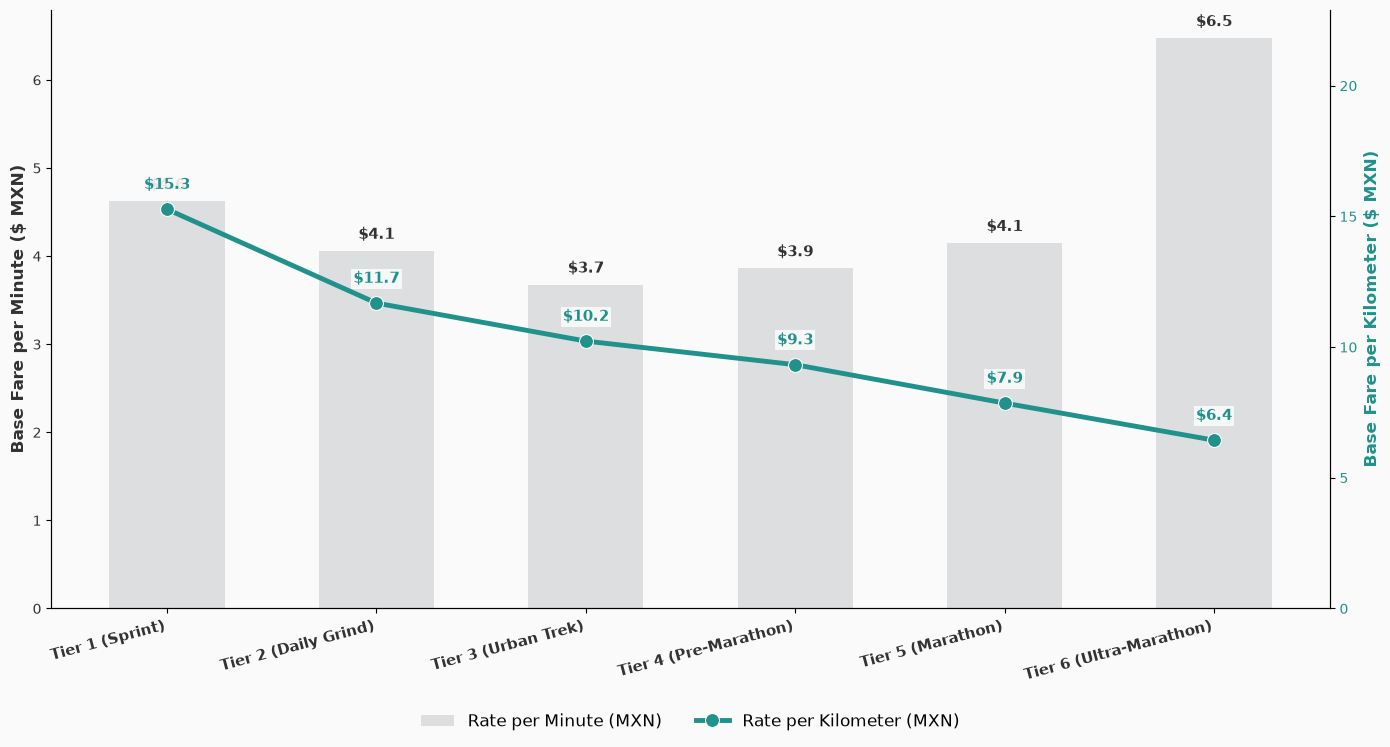

In [5]:
profiles = profiles_purified  # local alias to match the plotting code below

print("Generating the dual-economic physics plot...")

fig, ax1 = plt.subplots(figsize=(14, 8), facecolor=PIENZA_BG)
ax1.set_facecolor(PIENZA_BG)

x = np.arange(len(profiles))
labels = profiles['archetype_name']

y_min = profiles['pesos_por_min'].values
y_km = profiles['pesos_por_km'].values

# Bars: pay rate per minute (left axis)
bars = ax1.bar(x, y_min, color=PIENZA_LIGHT_GREY, alpha=0.7, width=0.55, label='Rate per Minute (MXN)')

for p in bars:
    height = p.get_height()
    ax1.annotate(f'${height:.1f}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha='center', va='bottom', color=PIENZA_DARK, fontweight='bold', fontsize=11)

ax1.set_ylabel('Base Fare per Minute ($ MXN)', color=PIENZA_DARK, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PIENZA_DARK)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold', fontsize=11, color=PIENZA_DARK, rotation=15, ha="right")
ax1.grid(False)

# Line: pay rate per kilometer (right axis)
ax2 = ax1.twinx()
sns.lineplot(x=x, y=y_km, ax=ax2, color=PIENZA_TEAL,
             marker='o', markersize=10, linewidth=3.5,
             label='Rate per Kilometer (MXN)', legend=False)

for i, val in enumerate(y_km):
    y_offset = 12 if val > (y_km.max() * 0.4) else -20
    va_align = 'bottom' if y_offset > 0 else 'top'
    ax2.annotate(f'${val:.1f}',
                xy=(x[i], val),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha='center', va=va_align, color=PIENZA_TEAL, fontweight='bold', fontsize=11,
                bbox=dict(facecolor=PIENZA_BG, edgecolor='none', alpha=0.9, pad=1.5))

ax2.set_ylabel('Base Fare per Kilometer ($ MXN)', color=PIENZA_TEAL, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=PIENZA_TEAL)
ax2.set_ylim(bottom=0, top=y_km.max() * 1.5)

lines, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend().set_visible(False)
ax1.legend(lines + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, frameon=False, fontsize=12)

sns.despine(right=False, top=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### Purified physics — final insights

**1. Distance tax.** Per-km rate is highest for Sprints (~$15/km) and lowest for Ultra-Marathons (~$6/km) — a near-perfect diminishing-returns curve. Short trips carry a premium, long trips get a volume discount.

**2. Time paradox (U-shaped curve).** Per-minute rate is high for Sprints (offsets fixed deadhead cost), dips for medium trips (city traffic, no premium), then spikes again for Marathons (likely highway segments push effective speed and per-minute rate back up).

**Bottom line:** pay drops per additional km, and pay per minute depends on the "quality" of the time (traffic vs. highway), not just its quantity.

## Phase 5 — Incentive analysis

Uses the canonical k=6 archetype from Phase 2 (already attached to `df_master`) to see how incentive frequency and intensity (surge, turbo+, reservation, priority) vary by trip archetype.

#### 5.1 — Incentive frequency vs. intensity by archetype

Frequency vs. intensity of incentives by archetype...
Frequency of occurrence (%):


,surge_freq_%,turbo_plus_freq_%,reservation_freq_%,priority_freq_%
Tier 1 (13m),29.227193,22.951772,1.045904,3.137711
Tier 2 (26m),31.958042,30.699301,4.125874,7.622378
Tier 3 (42m),33.428844,28.462273,4.393505,7.640879
Tier 4 (57m),33.688699,36.247335,8.315565,8.528785
Tier 5 (83m),41.666667,35.416667,6.250000,10.416667
Tier 6 (224m),50.000000,0.000000,0.000000,0.000000


Average intensity (MXN, only when active):


,surge_avg_amount,turbo_plus_avg_amount,reservation_avg_amount,priority_avg_amount
Tier 1 (13m),11.176938,14.379747,40.521333,18.852667
Tier 2 (26m),14.723589,25.824556,49.672143,18.853390
Tier 3 (42m),15.822857,36.145638,56.676905,18.872941
Tier 4 (57m),14.860759,47.939882,74.974359,19.138148
Tier 5 (83m),18.950000,66.017941,81.785000,18.810000
Tier 6 (224m),6.000000,0.000000,0.000000,0.000000


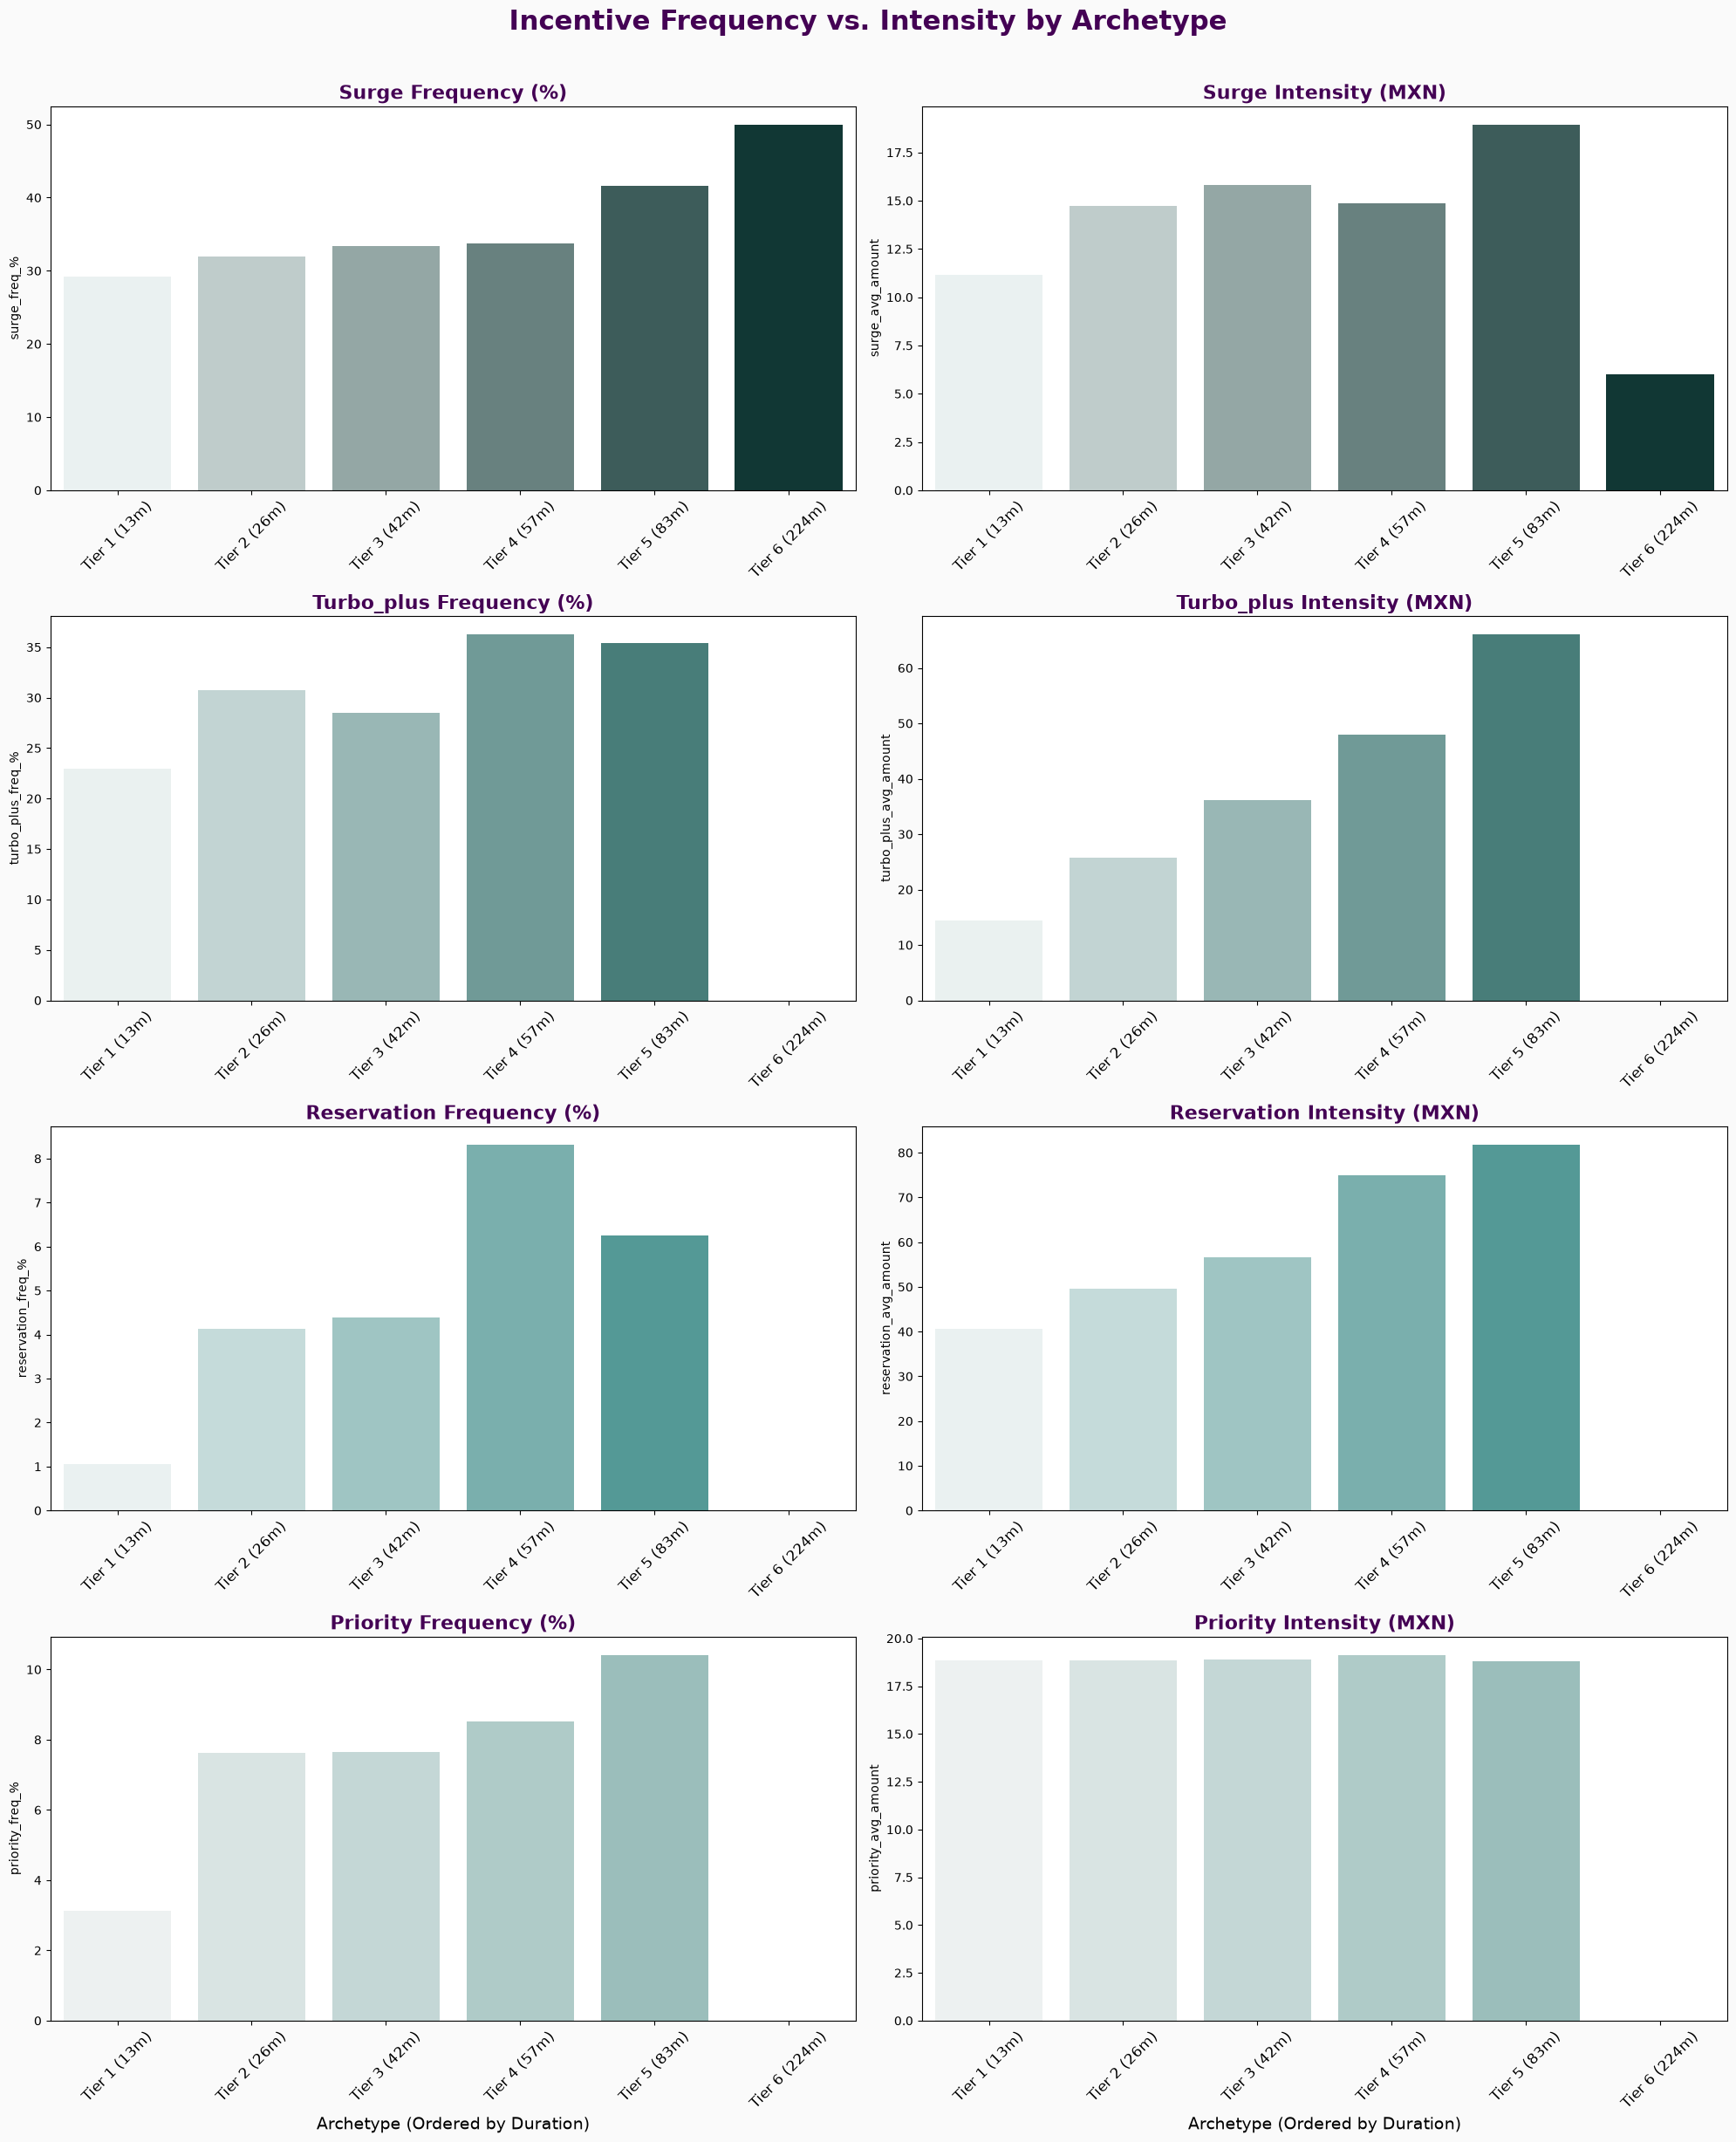

In [6]:
print("Frequency vs. intensity of incentives by archetype...")

df_incentive_analysis = df_master.copy()

incentive_types = ['surge', 'turbo_plus', 'reservation', 'priority']

df_freq = pd.DataFrame(index=archetype_names_ordered)
df_intensity = pd.DataFrame(index=archetype_names_ordered)

for incentive in incentive_types:
    is_col = f'is_{incentive}'
    amount_col = f'{incentive}_amount'

    df_incentive_analysis[is_col] = pd.to_numeric(df_incentive_analysis[is_col], errors='coerce').fillna(0).astype(int)
    df_incentive_analysis[amount_col] = pd.to_numeric(df_incentive_analysis[amount_col], errors='coerce')

    freq = df_incentive_analysis.groupby('archetype_name')[is_col].mean() * 100
    df_freq[f'{incentive}_freq_%'] = freq

    df_incentive_active = df_incentive_analysis[df_incentive_analysis[is_col] == 1]
    intensity = df_incentive_active.groupby('archetype_name')[amount_col].mean()
    df_intensity[f'{incentive}_avg_amount'] = intensity

df_intensity = df_intensity.fillna(0)

print("Frequency of occurrence (%):")
display(df_freq)
print("Average intensity (MXN, only when active):")
display(df_intensity)

fig, axes = plt.subplots(len(incentive_types), 2, figsize=(20, 25))
fig.suptitle('Incentive Frequency vs. Intensity by Archetype', fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

# Teal-shade family per incentive type (canon palette, no off-brand hues)
# n_colors matches the number of archetype bars per subplot
teal_shades = ['#0b3d39', '#146b64', '#21918c', '#7fb8b3']
n_bars = len(archetype_names_ordered)
palettes = {
    'surge': sns.light_palette(teal_shades[0], n_colors=n_bars),
    'turbo_plus': sns.light_palette(teal_shades[1], n_colors=n_bars),
    'reservation': sns.light_palette(teal_shades[2], n_colors=n_bars),
    'priority': sns.light_palette(teal_shades[3], n_colors=n_bars),
}

for i, incentive in enumerate(incentive_types):
    freq_col = f'{incentive}_freq_%'
    amount_col = f'{incentive}_avg_amount'

    sns.barplot(data=df_freq, x=df_freq.index, y=freq_col, ax=axes[i, 0], palette=palettes[incentive])
    axes[i, 0].set_title(f'{incentive.capitalize()} Frequency (%)', fontsize=16, fontweight='bold', color=PIENZA_PURPLE)
    axes[i, 0].set_xlabel('')
    axes[i, 0].tick_params(axis='x', rotation=45, labelsize=12)

    sns.barplot(data=df_intensity, x=df_intensity.index, y=amount_col, ax=axes[i, 1], palette=palettes[incentive])
    axes[i, 1].set_title(f'{incentive.capitalize()} Intensity (MXN)', fontsize=16, fontweight='bold', color=PIENZA_PURPLE)
    axes[i, 1].set_xlabel('')
    axes[i, 1].tick_params(axis='x', rotation=45, labelsize=12)

for ax in axes[-1, :]:
    ax.set_xlabel('Archetype (Ordered by Duration)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### The incentive toolkit

- **Surge** — frequency and amount both rise with trip duration. A risk premium for "painful" (long/undesirable) trips.
- **Turbo+** — frequency flat across tiers; amount scales with duration (artifact of being an hourly bonus). A general activity incentive, not reactive.
- **Reservation** — amount scales almost linearly with duration, peaking at Marathons. Signals a "high-value mission" premium the platform pays to secure reliability on its biggest commitments.

## Phase 6 — EPH erosion panel

Profiles four EPH (earnings-per-hour) index variants by archetype, first as a mean-based bar chart, then as a full distribution (boxplot) — the two disagree in an instructive way, diagnosed below.

#### 6.1 — EPH deviation from baseline, by archetype (mean)

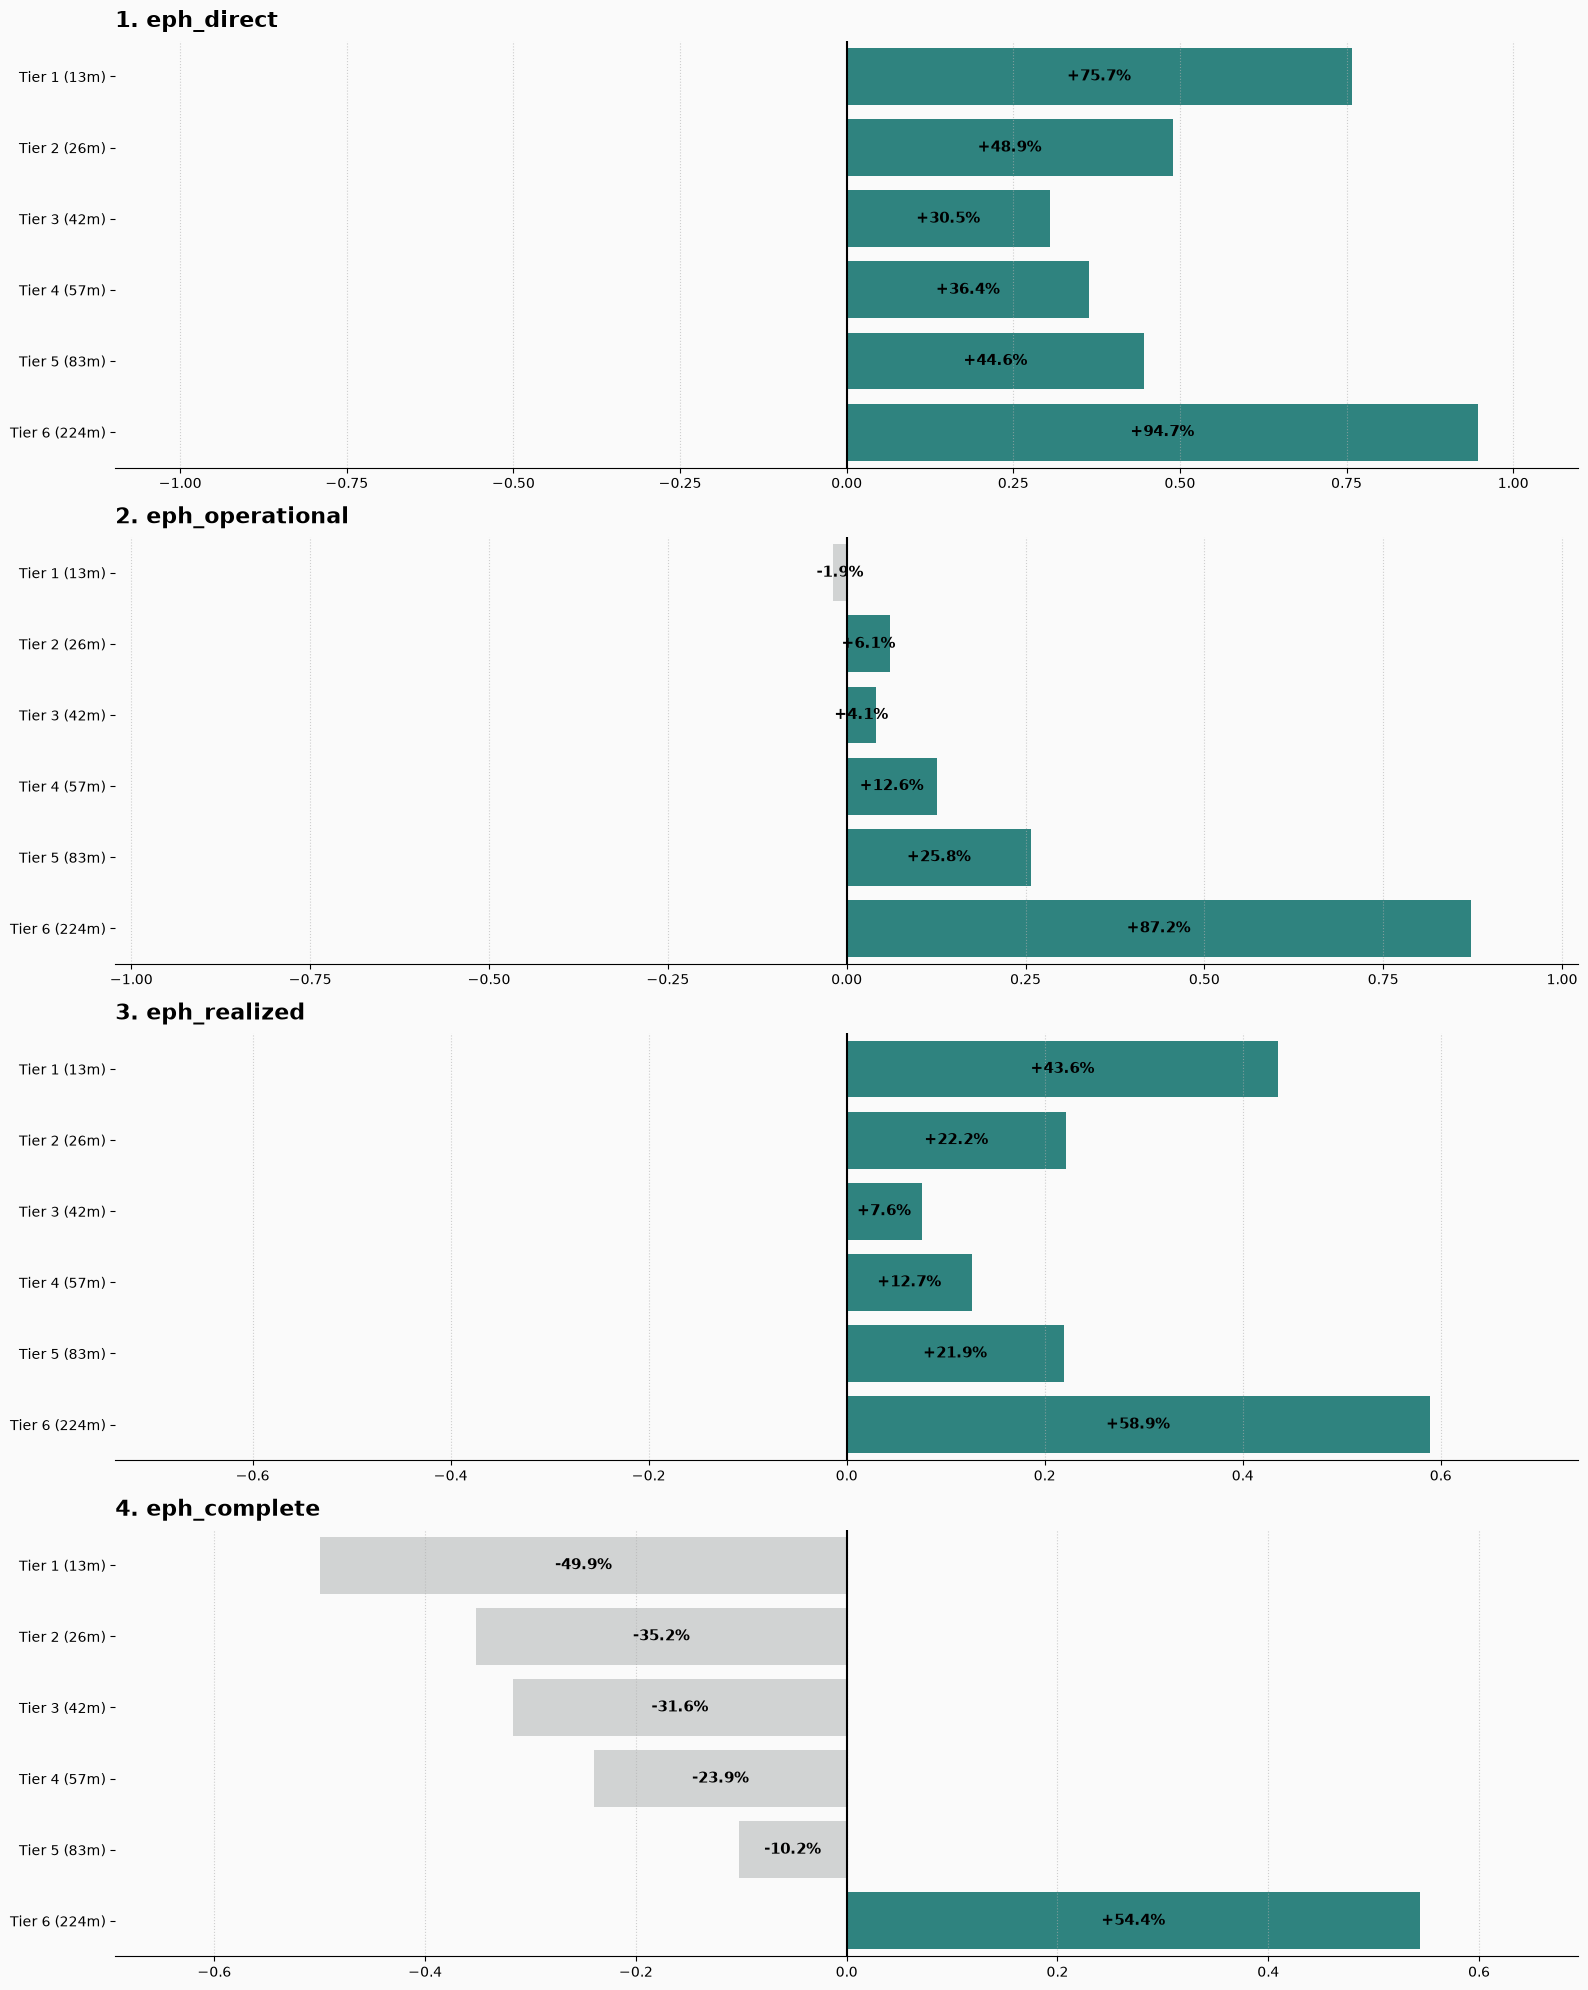

In [7]:
eph_metrics_eda = {
    'eph_direct_index': '1. eph_direct',
    'eph_operational_index': '2. eph_operational',
    'eph_realized_index_eda': '3. eph_realized',
    'eph_complete_index_eda': '4. eph_complete'
}

for col in eph_metrics_eda.keys():
    df_master[col] = pd.to_numeric(df_master[col], errors='coerce').fillna(0)

eph_profile = df_master.groupby('archetype_name')[list(eph_metrics_eda.keys())].mean()
eph_profile = eph_profile.reindex(archetype_names_ordered)

fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharey=True, facecolor=PIENZA_BG)
ax_flat = axes.flatten()

for i, (col, title) in enumerate(eph_metrics_eda.items()):
    ax = ax_flat[i]
    ax.set_facecolor(PIENZA_BG)

    plot_df = eph_profile.reset_index()
    plot_df['deviation'] = plot_df[col] - 1.0

    colors = [PIENZA_TEAL if x >= 0 else PIENZA_LIGHT_GREY for x in plot_df['deviation']]

    sns.barplot(data=plot_df, y='archetype_name', x='deviation', ax=ax, palette=colors, orient='h')
    ax.axvline(0, color='black', linestyle='-', linewidth=1.5)

    ax.set_title(title, fontsize=16, fontweight='bold', color='black', loc='left', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

    max_abs_dev = plot_df['deviation'].abs().max()
    limit = max(max_abs_dev + 0.15, 0.4)
    ax.set_xlim(-limit, limit)

    for p in ax.patches:
        dev = p.get_width()
        if abs(dev) < 0.001:
            continue
        label_text = f"{dev*100:+.1f}%"
        x_pos = dev / 2
        ax.text(x_pos, p.get_y() + p.get_height() / 2, label_text,
                va='center', ha='center', fontweight='bold', color='black', fontsize=11)

    sns.despine(ax=ax, left=True, bottom=False)
    ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Mean vs. median: why the two panels disagree

EPH is right-skewed (a long tail of highly profitable outlier trips). The mean (bar chart, 6.1) gets pulled up by those outliers; the median (boxplot, 6.2) reflects the *typical* trip and stays below baseline.

**Both are true:** the median says the typical trip isn't profitable even after accounting for pickup time; the mean says a few standout trips per archetype are enough to make the archetype look profitable in aggregate. Together they argue for an active selection policy — hunt the positive outliers rather than accept the "typical" trip passively.

---

## Appendix — variable journey

```mermaid
flowchart TD
    offers["offers + engineered_features\n(pienza.db)"] --> df_master["df_master"]
    df_master --> tournament["2.1: k=2 / k=6 tournament\n(features_core)"]
    tournament --> profiles_k6["profiles_k6\n(archetype_name, k=6 canonical)"]
    profiles_k6 --> df_master2["df_master\n(+cluster_fisico, +archetype_name)"]
    df_master2 --> rate31["3.1: rate analysis\n(pesos_por_min / pesos_por_km)"]
    df_master2 --> incentives["5.1: incentive frequency\n& intensity by archetype"]
    df_master2 --> eph["6.1 / 6.2: eph_profile\n(mean vs. median)"]

    offers --> df_incentives["4.1: df_incentives\n(+base_fare)"]
    df_incentives --> profiles_purified["profiles_purified\n(purified archetypes, separate k=6)"]
    profiles_purified --> dualplot["4.2: dual-economic plot"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```
